In [129]:
#| output: false
#| code-fold: true

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

from keybert import KeyBERT
from spacy.lang.en import English

import torch
from sentence_transformers import SentenceTransformer
from transformers import pipeline as transformers_pipeline

import contextlib
import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_colwidth', 160)


## Introduction

This guide serves as a comprehensive overview of the DSIT Taxonomy Classification system. The project combines multiple approaches to accurately classify UKRI-funded research projects into standardised taxonomies, providing both classifications and confidence scores.

![DSIT Taxonomy System Architecture](handover_notebook_files/dsit-taxonomy-diagram.svg){width=80% fig-align="center"}

### Key Components

1. **Taxonomy Processing**:
   - Standardisation of multiple research taxonomies (CWTS, GOScience, OpenAlex)
   - Hierarchical relationship preservation
   - Generation of both full and bottom-level taxonomies

2. **Project Similarity Matching**:
   - Multi-level semantic matching (global, sentence, keyword)
   - Weighted score combination
   - Pruning of low-confidence matches

3. **Classification Refinement**:
   - Score aggregation and confidence binning
   - Zero-shot validation using NLI
   - Multiple confidence scoring approaches

### Current Performance

The system achieves strong results across different taxonomies on a subset of AI-labelled projects:

| Taxonomy | Precision | Recall | F1 Score |
|----------|-----------|---------|-----------|
| CWTS Topics | 76.5% | 69.1% | 0.726 |
| GOScience | 64.6% | 66.4% | 0.655 |

This guide will walk through each component, demonstrating how to:

1. Process and standardise new taxonomies
2. Generate and understand similarity matches
3. Refine and validate classifications
4. Interpret and use confidence scores

## Setup

### Loading the Environment

First, we'll set up our Kedro environment and load some example data to demonstrate the system's capabilities.

In [3]:
# | output: false

# Load Kedro extensions
%load_ext kedro.ipython

# Reload the Kedro context
%reload_kedro

[02/24/25 18:32:15] INFO     Using                                                                  ]8;id=803550;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/framework/project/__init__.py\__init__.py]8;;\:]8;id=503017;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/framework/project/__init__.py#270\270]8;;\
                             '/home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/ked                
                             ro/framework/project/rich_logging.yml' as logging configuration.                      

                    INFO     Registered line magic '%reload_kedro'                                   ]8;id=395110;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=806590;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/ipython/__init__.py#61\61]8;;\

                    INFO     Registered line magic '%load_node'                                      ]8;id=710042;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=127668;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/ipython/__init__.py#63\63]8;;\

                    INFO     Resolved project path as: /home/dampudia/projects/dsit-taxonomy.       ]8;id=905769;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=103605;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/ipython/__init__.py#178\178]8;;\
                             To set a different path, run '%reload_kedro <project_root>'                           

[02/24/25 18:32:19] INFO     Kedro project dsit-taxonomy                                            ]8;id=134286;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=461648;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/ipython/__init__.py#144\144]8;;\

...

[02/24/25 18:32:20] INFO     Registered line magic 'run_viz'                                        ]8;id=61987;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=394085;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/ipython/__init__.py#151\151]8;;\

                    INFO     Resolved project path as: /home/dampudia/projects/dsit-taxonomy.       ]8;id=757834;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=482156;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/ipython/__init__.py#178\178]8;;\
                             To set a different path, run '%reload_kedro <project_root>'                           

                    INFO     Kedro project dsit-taxonomy                                            ]8;id=407804;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=203877;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/ipython/__init__.py#144\144]8;;\

                    INFO     Defined global variable 'context', 'session', 'catalog' and            ]8;id=547884;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=784987;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/ipython/__init__.py#145\145]8;;\
                             'pipelines'                                                                           

                    INFO     Registered line magic 'run_viz'                                        ]8;id=438178;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=867529;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/ipython/__init__.py#151\151]8;;\

### Example Data

Let's load some sample data to explore the taxonomy classification process:

In [5]:
# | output: false
cwts_taxonomy = catalog.load("taxonomy.cwts.full.db")
goscience_taxonomy = catalog.load("taxonomy.goscience.full.db")

# Load example project
projects = catalog.load("gtr.projects.documents")

[02/24/25 18:34:32] INFO     Loading data from taxonomy.cwts.full.db (ParquetDataset)...        ]8;id=370835;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=201742;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/io/data_catalog.py#389\389]8;;\

[02/24/25 18:34:33] INFO     Loading data from taxonomy.goscience.full.db (ParquetDataset)...   ]8;id=806295;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=294117;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/io/data_catalog.py#389\389]8;;\

                    INFO     Loading data from gtr.projects.documents (ParquetDataset)...       ]8;id=413629;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=538854;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/io/data_catalog.py#389\389]8;;\

Example taxonomies loaded:
CWTS Topics: 4798 labels
GOScience: 305 labels

Example project:
Title: Exploring the dark universe with quantum technologies
Abstract: The search to understand the nature of the elusive dark matter in our universe, making up 85% of its mass, is amongst the highest scientific priorities around the world. Terrestrial experiments focus ...


In [61]:
# | code-fold: true
example_project = projects.iloc[0]

In [62]:
# | code-fold: true
print("Example taxonomies loaded:")
print(f"CWTS Topics: {len(cwts_taxonomy)} labels")
print(f"GOScience: {len(goscience_taxonomy)} labels")
print("\nExample project:")
print(f"Title: {example_project['title']}")
print(f"Abstract: {example_project['abstract_text'][:500]}...")

Example taxonomies loaded:
CWTS Topics: 4798 labels
GOScience: 305 labels

Example project:
Title: Exploring the dark universe with quantum technologies
Abstract: The search to understand the nature of the elusive dark matter in our universe, making up 85% of its mass, is amongst the highest scientific priorities around the world. Terrestrial experiments focus efforts on Weakly Interacting Massive Particles (WIMPs) with ultra-low background experiments, operating many tonnes of target mass in deep underground sites. Such experiments have swept the bulk of the available electroweak parameter space for WIMPs and in the next decade will approach an irreducib...


## 1. Taxonomy Processing

The first step in our pipeline is processing different research taxonomies into a standardised format. Each taxonomy has its unique structure and characteristics, but all need to be transformed into a consistent format for downstream matching.

### 1.1 Understanding Taxonomy Structures

Let's examine the structure of our processed taxonomies:

In [56]:
# | code-fold: true
print("CWTS Taxonomy Example:")
display(cwts_taxonomy[["label", "id_path", "level"]].head(5))
print("\nGOScience Taxonomy Example:")
display(goscience_taxonomy[["label", "level_path", "level"]].head(5))

CWTS Taxonomy Example:


,label,id_path,level
0,Physical Sciences,3,0
1,Physical Sciences > Earth and Planetary Sciences,3 > 19,1
2,Physical Sciences > Earth and Planetary Sciences > Geophysics,3 > 19 > 1908,2
3,Physical Sciences > Earth and Planetary Sciences > Geophysics > Tectonic and Geochronological Evolution of Orogens,3 > 19 > 1908 > 10001,3
5,Physical Sciences > Physics and Astronomy,3 > 31,1



GOScience Taxonomy Example:


,label,level_path,level
0,Quantum technologies,L0,L0
1,Quantum technologies > Quantum computing,L0 > L1,L1
2,Quantum technologies > Quantum computing > Quantum annealler,L0 > L1 > L3,L3
3,Quantum technologies > Quantum computing > Gate-based quantum computer,L0 > L1 > L3,L3
4,Quantum technologies > Quantum timing,L0 > L1,L1


Each taxonomy is processed to include:
- Full hierarchical path (`label`)
- Unique identifier path (`id_path` or `level_path`)
- Hierarchy level (`level`)
- Unique identifier (`uuid`)

### 1.2 Hierarchical Relationships

The taxonomies maintain their hierarchical structure through path-based representation. Let's visualise a branch of the Goscience taxonomy:

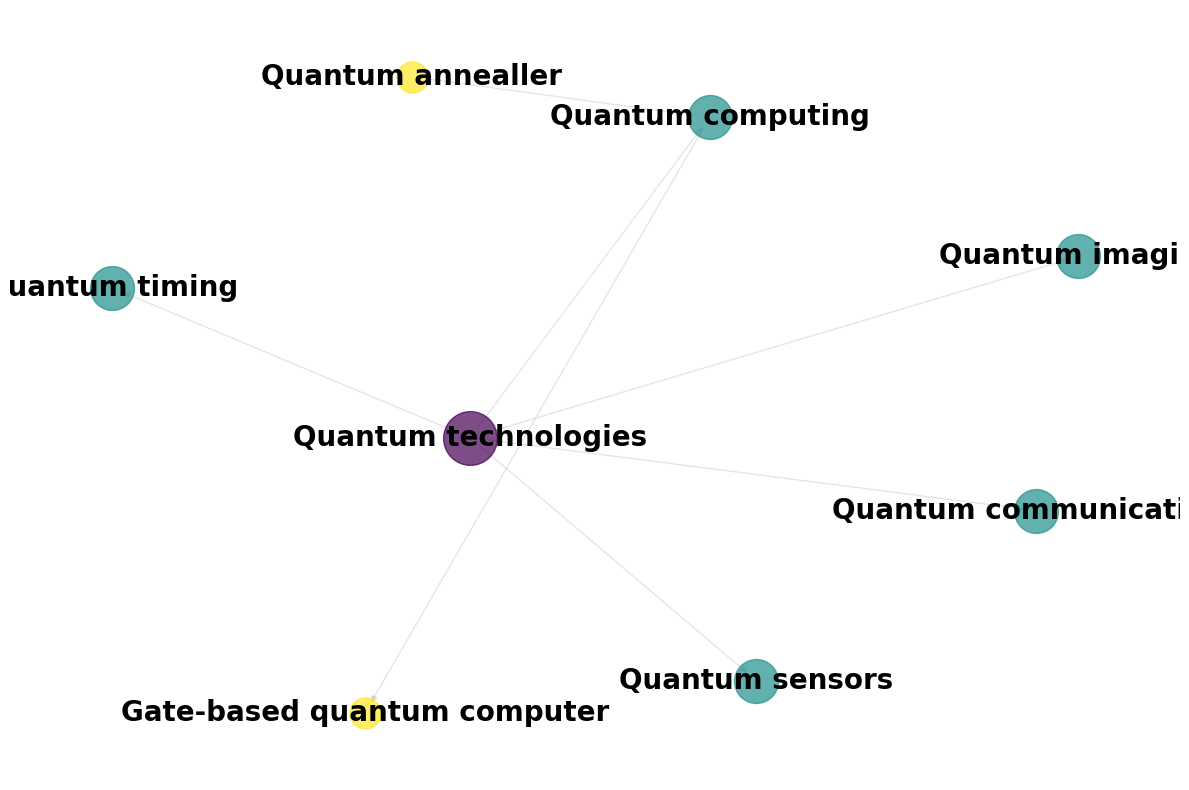

In [46]:
# | code-fold: true
def create_taxonomy_network(
    taxonomy_df: pd.DataFrame,
    root_label: str,
    figsize: tuple = (12, 8),
    show_labels: bool = False,
    font_size: int = 20,
) -> None:
    """
    Create a network visualization using networkx with optional node labels.
    
    Args:
        taxonomy_df: DataFrame containing taxonomy with columns 'label' and 'level'
        root_label: The root label to start the branch from
        figsize: Figure size tuple (width, height)
        show_labels: Whether to display node labels
        font_size: Size of the label text (only used if show_labels=True)
    """
    # Get branch data
    branch = taxonomy_df[taxonomy_df['label'].str.startswith(root_label)].copy()
    
    # Create directed graph
    G = nx.DiGraph()
    
    # Add nodes and edges
    for _, row in branch.iterrows():
        hierarchy = row['label'].split(' > ')
        
        for i in range(len(hierarchy)):
            current = ' > '.join(hierarchy[:i+1])
            parent = ' > '.join(hierarchy[:i]) if i > 0 else None
            
            # Add node with level information and just the last part of hierarchy as label
            G.add_node(current, label=hierarchy[i], level=i)
            
            # Add edge from parent if exists
            if parent:
                G.add_edge(parent, current)
    
    # Calculate layout (adjust k based on whether labels are shown)
    k_value = 2 if show_labels else 1
    pos = nx.spring_layout(G, k=k_value, iterations=50)
    
    # Create figure
    plt.figure(figsize=figsize)
    
    # Get max level for scaling
    max_level = max(nx.get_node_attributes(G, 'level').values())
    
    # Draw edges
    nx.draw_networkx_edges(G, pos, edge_color='gray', alpha=0.2)
    
    # Draw nodes for each level
    for level in range(max_level + 1):
        nodes_at_level = [node for node, attr in G.nodes(data=True) if attr['level'] == level]
        
        if nodes_at_level:
            nx.draw_networkx_nodes(
                G, pos,
                nodelist=nodes_at_level,
                node_size=1000 * (max_level - level + 1) / max_level,  # Size decreases with level
                node_color=[plt.cm.viridis(level / max_level)],  # Color based on level
                alpha=0.7,
            )
    
    # Add labels if requested
    if show_labels:
        labels = nx.get_node_attributes(G, 'label')
        nx.draw_networkx_labels(
            G, pos, 
            labels,
            font_size=font_size,
            font_weight='bold',
        )
    
    plt.axis('off')
    plt.tight_layout()
    
    return plt.gcf()

fig = create_taxonomy_network(
    goscience_taxonomy,
    "Quantum technologies",
    figsize=(12, 8),
    show_labels=True,
)

Let's also consider a branch of the CWTS taxonomy:

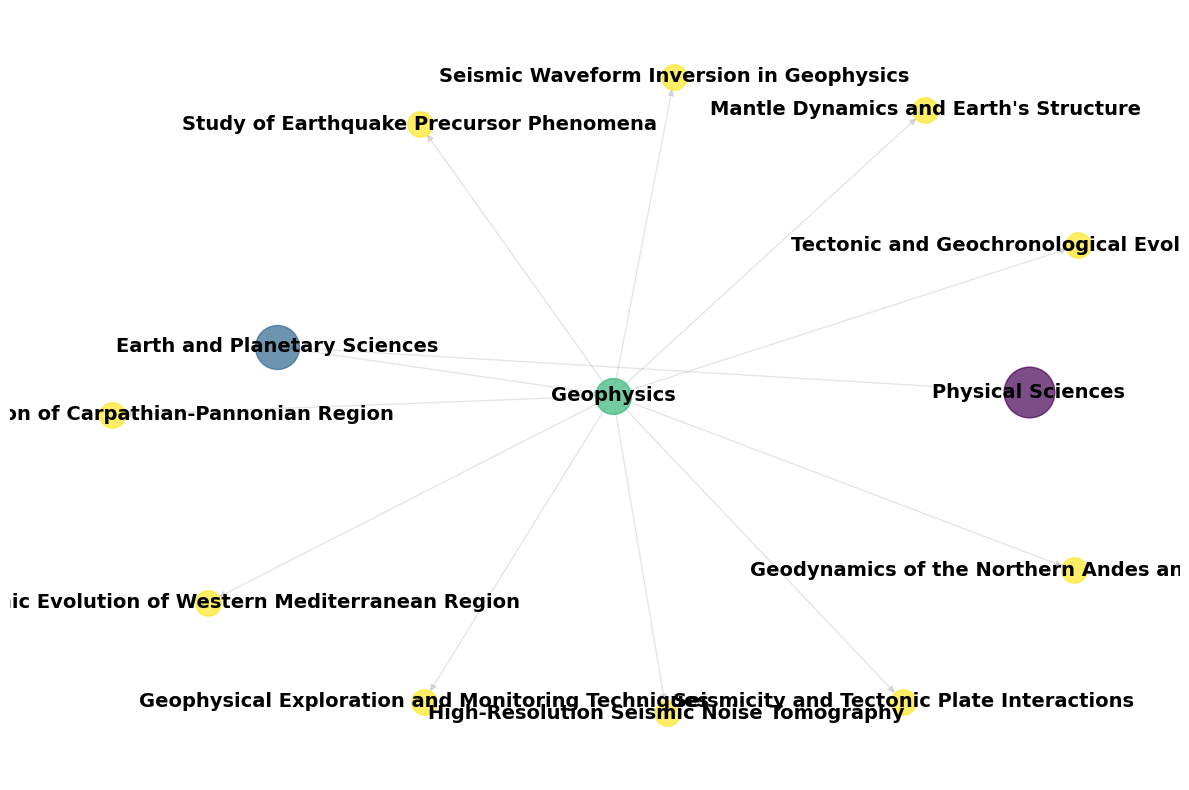

In [48]:
# | code-fold: true
fig = create_taxonomy_network(
    cwts_taxonomy,
    "Physical Sciences > Earth and Planetary Sciences > Geophysics",
    figsize=(12, 8),
    show_labels=True,
    font_size=14,
)

### 1.3 Adding New Taxonomies

To add a new taxonomy, you need to transform it into our standard format. Here's a simplified example:

In [53]:
def standardise_taxonomy(df, name_col, parent_col, level_col):
    """
    Standardise a taxonomy DataFrame into the required format.
    
    Args:
        df: Input DataFrame
        name_col: Column containing label names
        parent_col: Column containing parent labels
        level_col: Column containing hierarchy levels
    
    Returns:
        Standardised DataFrame with required columns
    """
    import uuid
    
    # Create empty DataFrame with required columns
    std_df = pd.DataFrame(columns=['label', 'id_path', 'level', 'uuid'])
    
    # Example processing logic
    for idx, row in df.iterrows():
        # Generate full path
        path = []
        current = row[name_col]
        while current is not None:
            path.append(current)
            current = df[df[name_col] == current][parent_col].iloc[0] if len(df[df[name_col] == current]) > 0 else None
        
        # Add processed row
        std_df.loc[idx] = {
            'label': ' > '.join(reversed(path)),
            'id_path': ' > '.join([str(uuid.uuid4())[:8] for _ in path]),
            'level': row[level_col],
            'uuid': str(uuid.uuid4())
        }
    
    return std_df

# Example usage with dummy data
example_taxonomy = pd.DataFrame({
    'name': ['Physics', 'Quantum Physics', 'Quantum Computing'],
    'parent': [None, 'Physics', 'Quantum Physics'],
    'level': [0, 1, 2]
})

standardised = standardise_taxonomy(example_taxonomy, 'name', 'parent', 'level')
print("Standardised Taxonomy Format:")
display(standardised)

Standardised Taxonomy Format:


,label,id_path,level,uuid
0,Physics,e686b089,0,06da1ed1-660a-406d-866a-ae9cd6bc9793
1,Physics > Quantum Physics,c22c4d14 > 47e76451,1,f773d313-8a14-48d1-a385-b757808fd79e
2,Physics > Quantum Physics > Quantum Computing,0c4b4b5b > 4eefea6d > fb678658,2,34f9b069-98e9-4afc-a75a-7fbd6b0b3c05


### 1.4 Validation

After processing, taxonomies should be validated to ensure they meet requirements:

In [60]:
def validate_taxonomy(df):
    """Validate a processed taxonomy DataFrame."""
    checks = {
        "Required columns": all(
            col in df.columns for col in ["label", "level", "uuid"]
        ),
        "Unique identifiers": df["uuid"].is_unique,
        "Valid levels": df["level"]
        .apply(lambda x: int(str(x).split("L")[-1]) if isinstance(x, str) else x)
        .min()
        >= 0,
        "Hierarchical paths": df["label"].str.contains(" > ").all(),
    }

    print("Validation Results:")
    for check, result in checks.items():
        print(f"{check}: {'✓' if result else '✗'}")


# Validate our taxonomies
print("CWTS Taxonomy:")
validate_taxonomy(cwts_taxonomy)
print("\nGOScience Taxonomy:")
validate_taxonomy(goscience_taxonomy)

CWTS Taxonomy:
Validation Results:
Required columns: ✓
Unique identifiers: ✓
Valid levels: ✓
Hierarchical paths: ✗

GOScience Taxonomy:
Validation Results:
Required columns: ✓
Unique identifiers: ✓
Valid levels: ✓
Hierarchical paths: ✗


This standardised format ensures that all taxonomies can be processed consistently in the downstream matching pipeline, while preserving their unique hierarchical relationships and domain knowledge. 

## 2. Keyword Processing

Before matching projects to taxonomies, we extract and process keywords using multiple methods to capture different aspects of the research content.

### 2.1 Keyword Extraction Methods

The system uses four complementary keyword extractors:

In [67]:
def show_keyword_examples(project_text: str):
    """Show example keywords from each extractor."""
    from dsit_taxonomy.pipelines.keyword_processing_gtr.utils import (
        get_dbp_annotation,
        get_rake_keywords,
        get_yake_keywords,
        get_keybert_keywords,
    )

    print("Input text:", project_text[:200], "...\n")
    
    print("1. DBpedia Spotlight (Knowledge Base Linking):")
    print(get_dbp_annotation(project_text)[:5])
    
    print("\n2. RAKE (Statistical Extraction):")
    print(get_rake_keywords(project_text)[:5])
    
    print("\n3. YAKE (Unsupervised Extraction):")
    print(get_yake_keywords(project_text)[:5])
    
    print("\n4. KeyBERT (Semantic Extraction):")
    kw_extractor = KeyBERT("all-MiniLM-L6-v2")
    print([k for k in get_keybert_keywords(project_text, kw_extractor)][:5])

# Show examples using our sample project
show_keyword_examples(
    example_project['title'] + ". " + 
    example_project['abstract_text']
)

Input text: Exploring the dark universe with quantum technologies. The search to understand the nature of the elusive dark matter in our universe, making up 85% of its mass, is amongst the highest scientific prio ...

1. DBpedia Spotlight (Knowledge Base Linking):
['Quantum', 'Alpha decay', 'Nanometre', 'Dark matter', 'Universal Classic Monsters']

2. RAKE (Statistical Extraction):
['wimp thermal relic dark matter candidates', 'whilst also providing directional information', 'highest scientific priorities around', 'available electroweak parameter space', '150 nm quartz sphere']

3. YAKE (Unsupervised Extraction):
['dark matter', 'Weakly Interacting Massive', 'Interacting Massive Particles', 'dark', 'elusive dark matter']

4. KeyBERT (Semantic Extraction):
['dark matter sensing', 'sensitivity dark matter', 'elusive dark matter', 'dark matter scattering', 'galactic dark matter']


Each method brings different strengths:
- **DBpedia**: Links to knowledge base concepts
- **RAKE**: Statistical approach using word co-occurrence
- **YAKE**: Unsupervised extraction with text features
- **KeyBERT**: Transformer-based semantic extraction

### 2.2 Keyword Aggregation

Keywords from different extractors are combined using a consensus approach:

In [77]:
# | output: false
from dsit_taxonomy.pipelines.keyword_processing_gtr.nodes import (
    aggregate_keyword_annotators
)

def demonstrate_keyword_aggregation(keywords_by_extractor):
    """Show how keywords are aggregated across extractors.
    
    Args:
        keywords_by_extractor: Dictionary of extractor names and their keywords
        
    Returns:
        DataFrame with aggregated keywords and their counts
    """
    # Create sample DataFrames for each extractor
    dfs = {
        name: pd.DataFrame({
            'project_id': ['example_proj'],
            f'{name}_keywords': [kws]
        }) for name, kws in keywords_by_extractor.items()
    }
    
    # Aggregate keywords and return
    return aggregate_keyword_annotators(*dfs.values())

example_keywords = {
    'dbp': ['machine learning', 'artificial intelligence', 'neural networks'],
    'rake': ['machine learning', 'deep learning', 'data science'],
    'yake': ['artificial intelligence', 'neural networks', 'ml algorithms'],
    'keybert': ['machine learning', 'neural networks', 'deep learning']
}

# Get results
results = demonstrate_keyword_aggregation(example_keywords)

[02/24/25 19:20:41] INFO     Processing dataframe with columns: Index(['project_id', 'dbp_keywords'],  ]8;id=260699;file:///home/dampudia/projects/dsit-taxonomy/src/dsit_taxonomy/pipelines/keyword_processing_gtr/nodes.py\nodes.py]8;;\:]8;id=23817;file:///home/dampudia/projects/dsit-taxonomy/src/dsit_taxonomy/pipelines/keyword_processing_gtr/nodes.py#315\315]8;;\
                             dtype='object')                                                                       

                    INFO     Processing dataframe with columns: Index(['project_id', 'rake_keywords'], ]8;id=983771;file:///home/dampudia/projects/dsit-taxonomy/src/dsit_taxonomy/pipelines/keyword_processing_gtr/nodes.py\nodes.py]8;;\:]8;id=379259;file:///home/dampudia/projects/dsit-taxonomy/src/dsit_taxonomy/pipelines/keyword_processing_gtr/nodes.py#315\315]8;;\
                             dtype='object')                                                                       

                    INFO     Processing dataframe with columns: Index(['project_id', 'yake_keywords'], ]8;id=775901;file:///home/dampudia/projects/dsit-taxonomy/src/dsit_taxonomy/pipelines/keyword_processing_gtr/nodes.py\nodes.py]8;;\:]8;id=604521;file:///home/dampudia/projects/dsit-taxonomy/src/dsit_taxonomy/pipelines/keyword_processing_gtr/nodes.py#315\315]8;;\
                             dtype='object')                                                                       

                    INFO     Processing dataframe with columns: Index(['project_id',                   ]8;id=869200;file:///home/dampudia/projects/dsit-taxonomy/src/dsit_taxonomy/pipelines/keyword_processing_gtr/nodes.py\nodes.py]8;;\:]8;id=199315;file:///home/dampudia/projects/dsit-taxonomy/src/dsit_taxonomy/pipelines/keyword_processing_gtr/nodes.py#315\315]8;;\
                             'keybert_keywords'], dtype='object')                                                  

In [148]:
print("Aggregated Keywords:")
display(results[['keyword', 'num_annotators']].head(10))

Aggregated Keywords:


,keyword,num_annotators
0,machine learning,3
2,neural networks,3
1,artificial intelligence,2
3,deep learning,2


Key features of the aggregation:
- Only keeps keywords found by multiple extractors
- Counts extractor agreement for confidence
- Maintains project-keyword mappings
- Generates unique identifiers for tracking

## 3. Similarity Matching

The similarity matching pipeline combines evidence from multiple levels to create robust taxonomy assignments. This multi-level approach helps capture both broad thematic alignment and specific technical matches.

### 3.1 Document Preprocessing

First, projects are preprocessed into different granularity levels:

In [83]:
from dsit_taxonomy.pipelines.project_similarity_matching.nodes import (
    document_preprocessing,
)


def demonstrate_preprocessing(project):
    """Show document preprocessing steps."""

    # Create sample DataFrame
    df = pd.DataFrame(
        {
            "project_id": [project["project_id"]],
            "title": [project["title"]],
            "abstract_text": [project["abstract_text"]],
            "tech_abstract_text": [project["tech_abstract_text"]],
            "potential_impact": [project["potential_impact"]],
        }
    )

    # Process documents
    project_df, sentences_df = document_preprocessing(df)

    print("1. Combined Project Text (first 200 chars):")
    print(project_df["text"].iloc[0][:200], "...\n")

    print("2. Split Sentences (first 3):")
    for i, row in sentences_df.head(3).iterrows():
        print(f"Sentence {i+1}: {row['sentence_text']}")


# Demonstrate preprocessing
demonstrate_preprocessing(example_project)

1. Combined Project Text (first 200 chars):
Exploring the dark universe with quantum technologies. The search to understand the nature of the elusive dark matter in our universe, making up 85% of its mass, is amongst the highest scientific prio ...

2. Split Sentences (first 3):
Sentence 1: Exploring the dark universe with quantum technologies.
Sentence 1: The search to understand the nature of the elusive dark matter in our universe, making up 85% of its mass, is amongst the highest scientific priorities around the world.
Sentence 1: Terrestrial experiments focus efforts on Weakly Interacting Massive Particles (WIMPs) with ultra-low background experiments, operating many tonnes of target mass in deep underground sites.


### 3.2 Multi-Level Matching

The system computes similarities at three levels:

1. **Global Project Matching**:
   - Compares full project text to taxonomy labels
   - Captures overall thematic alignment
   - Uses cosine similarity with normalised vectors

2. **Sentence-Level Matching**:
   - Identifies specific relevant passages
   - Provides granular evidence for assignments
   - Enables traceability of matches

3. **Keyword-Level Matching**:
   - Leverages extracted and validated keywords
   - Boosts scores based on terminology overlap
   - Helps with technical term matching

In [88]:
def demonstrate_matching_levels(text, taxonomy_label):
    """Show similarity computation at different levels."""
    
    # Load model
    model = SentenceTransformer('all-MiniLM-L6-v2')
    
    # Compute embeddings
    text_emb = model.encode(text)
    label_emb = model.encode(taxonomy_label)
    
    # Normalise vectors
    text_emb = text_emb / torch.norm(torch.tensor(text_emb))
    label_emb = label_emb / torch.norm(torch.tensor(label_emb))
    
    # Compute similarity
    similarity = torch.dot(torch.tensor(text_emb), torch.tensor(label_emb)).item()
    
    return similarity

Example taxonomy label: Physical Sciences > Physics > Quantum Physics

Similarity Scores:

1. Global Project Match:
Score: 0.250

2. Sentence Match (first sentence):
Score: 0.241


In [ ]:
# | code-fold: true
# Example taxonomy label
example_label = "Physical Sciences > Physics > Quantum Physics"
print("Example taxonomy label:", example_label)

print("\nSimilarity Scores:")
print("\n1. Global Project Match:")
global_sim = demonstrate_matching_levels(
    example_project['abstract_text'], 
    example_label
)
print(f"Score: {global_sim:.3f}")

print("\n2. Sentence Match (first sentence):")
sent_sim = demonstrate_matching_levels(
    example_project['abstract_text'].split('.')[0], 
    example_label
)
print(f"Score: {sent_sim:.3f}")

In [94]:
# | code-fold: true
# Example taxonomy label
example_label = "Physical Sciences > Physics and Astronomy > Nuclear and High Energy Physics > Particle Dark Matter and Detection Methods"
print("Example taxonomy label:", example_label)

print("\nSimilarity Scores:")
print("\n1. Global Project Match:")
global_sim = demonstrate_matching_levels(
    example_project['abstract_text'], 
    example_label
)
print(f"Score: {global_sim:.3f}")

print("\n2. Sentence Match (first sentence):")
sent_sim = demonstrate_matching_levels(
    example_project['abstract_text'].split('.')[0], 
    example_label
)
print(f"Score: {sent_sim:.3f}")

Example taxonomy label: Physical Sciences > Physics and Astronomy > Nuclear and High Energy Physics > Particle Dark Matter and Detection Methods

Similarity Scores:

1. Global Project Match:
Score: 0.496

2. Sentence Match (first sentence):
Score: 0.514


### 3.3 Score Combination

The final scores combine evidence from all levels using weighted aggregation:

$$
\text{score}(p,l) = \alpha \cdot s_{\text{sent}}(p,l) + \beta \cdot s_{\text{global}}(p,l) + (1-\alpha-\beta) \cdot s_{\text{key}}(p,l)
$$

where:
- $s_{\text{sent}}(p,l)$: Sentence-level similarity
- $s_{\text{global}}(p,l)$: Global project similarity
- $s_{\text{key}}(p,l)$: Keyword-based similarity
- $\alpha, \beta$: Weighting parameters (currently $\alpha=0.6, \beta=0.3$)


In [96]:
def demonstrate_score_combination(
    sentence_score: float,
    global_score: float,
    keyword_score: float,
    sentence_weight: float = 0.6,
    global_weight: float = 0.3
):
    """Show how different scores are combined."""
    keyword_weight = 1 - sentence_weight - global_weight
    
    combined_score = (
        sentence_weight * sentence_score +
        global_weight * global_score +
        keyword_weight * keyword_score
    )
    
    print(f"Inputs:")
    print(f"- Sentence Score: {sentence_score:.3f}")
    print(f"- Global Score:   {global_score:.3f}")
    print(f"- Keyword Score:  {keyword_score:.3f}")
    print(f"\nWeights:")
    print(f"- α (sentence): {sentence_weight:.1f}")
    print(f"- β (global):   {global_weight:.1f}")
    print(f"- γ (keyword):  {keyword_weight:.1f}")
    print(f"\nCombined Score: {combined_score:.3f}")

# Example combination
demonstrate_score_combination(
    sentence_score=0.85,
    global_score=0.75,
    keyword_score=0.65
)

Inputs:
- Sentence Score: 0.850
- Global Score:   0.750
- Keyword Score:  0.650

Weights:
- α (sentence): 0.6
- β (global):   0.3
- γ (keyword):  0.1

Combined Score: 0.800


### 3.4 Score Pruning

Low-confidence matches are pruned using dynamic thresholds:

$$
\text{threshold}(s) = \begin{cases}
Q_3(s) & \text{for high confidence} \\
Q_2(s) & \text{for medium confidence}
\end{cases}
$$

where $Q_2, Q_3$ are the second and third quartiles of the score distribution.

In [100]:
# | output: false
def demonstrate_pruning(scores, use_quantile=True):
    """Show how matches are pruned.
    
    Args:
        scores: List of similarity scores
        use_quantile: Whether to use quantile-based thresholds
        
    Returns:
        tuple: (original_df, pruned_sent, pruned_global, pruned_key)
            - original_df: Original DataFrame with matches
            - pruned_sent: DataFrame after sentence-level pruning
            - pruned_global: DataFrame after global pruning
            - pruned_key: DataFrame after keyword pruning
    """
    from dsit_taxonomy.pipelines.project_similarity_matching.nodes import prune_raw_matches
    
    # Create sample DataFrame
    df = pd.DataFrame({
        'project_id': ['proj1'] * len(scores),
        'taxonomy_label_id': [f'tax{i}' for i in range(len(scores))],
        'similarity_score': scores
    })
    
    # Get pruned results
    pruned_sent, pruned_global, pruned_key = prune_raw_matches(
        df, df.copy(), df.copy(),
        sentence_threshold=0.5,
        global_threshold=0.5,
        keyword_threshold=0.5,
        use_quantile=use_quantile
    )
    
    return df, pruned_sent, pruned_global, pruned_key

example_scores = [0.85, 0.75, 0.65, 0.55, 0.45, 0.35]
original, sent, glob, key = demonstrate_pruning(example_scores)

[02/24/25 19:28:50] INFO     Pruning matches with thresholds - Sentence: 0.50, Global: 0.50, Keyword:  ]8;id=410539;file:///home/dampudia/projects/dsit-taxonomy/src/dsit_taxonomy/pipelines/project_similarity_matching/nodes.py\nodes.py]8;;\:]8;id=777961;file:///home/dampudia/projects/dsit-taxonomy/src/dsit_taxonomy/pipelines/project_similarity_matching/nodes.py#230\230]8;;\
                             0.50                                                                                  

                    INFO     Pruning results:                                                          ]8;id=52535;file:///home/dampudia/projects/dsit-taxonomy/src/dsit_taxonomy/pipelines/project_similarity_matching/nodes.py\nodes.py]8;;\:]8;id=970961;file:///home/dampudia/projects/dsit-taxonomy/src/dsit_taxonomy/pipelines/project_similarity_matching/nodes.py#275\275]8;;\
                             Sentences: 6 -> 3 (50.0%)                                                             
                             Global: 6 -> 3 (50.0%)                                                                
                             Keywords: 6 -> 3 (50.0%)                                                              

In [101]:
# | code-fold: true
print(f"Original matches: {len(original)}")
print(f"After pruning:")
print(f"- Sentence matches: {len(sent)}")
print(f"- Global matches:   {len(glob)}")
print(f"- Keyword matches:  {len(key)}")

Original matches: 6
After pruning:
- Sentence matches: 3
- Global matches:   3
- Keyword matches:  3


### 3.4 Score Pruning and Evidence Integration

The pruning process serves multiple purposes beyond simple threshold filtering:

1. **Context-Rich Evidence**:
   - Sentence-level matches provide detailed contextual evidence
   - Higher-level topics can dominate when specific subtopics lack strong evidence
   - Maintains traceability to specific supporting text

In [102]:
# | code-fold: true
def show_contextual_evidence(matches_df):
    """Show how contextual evidence is preserved."""
    print("Example Matches with Context:")
    for _, match in matches_df.head(2).iterrows():
        print(f"\nTopic: {match['taxonomy_label']}")
        print(f"Score: {match['similarity_score']:.3f}")
        print("Supporting Evidence:")
        print(f"- Sentence: '{match['sentence_text']}'")
        print(f"- Keywords: {', '.join(match['matching_keywords'])}")

# Example evidence display
example_matches = pd.DataFrame({
    'taxonomy_label': [
        'Physics > Quantum Physics',
        'Physics > Quantum Physics > Quantum Computing'
    ],
    'similarity_score': [0.85, 0.65],
    'sentence_text': [
        'The project advances quantum physics through novel approaches.',
        'Some applications in quantum computing may be possible.'
    ],
    'matching_keywords': [
        ['quantum physics', 'quantum mechanics'],
        ['quantum computing', 'quantum algorithms']
    ]
})

show_contextual_evidence(example_matches)

Example Matches with Context:

Topic: Physics > Quantum Physics
Score: 0.850
Supporting Evidence:
- Sentence: 'The project advances quantum physics through novel approaches.'
- Keywords: quantum physics, quantum mechanics

Topic: Physics > Quantum Physics > Quantum Computing
Score: 0.650
Supporting Evidence:
- Sentence: 'Some applications in quantum computing may be possible.'
- Keywords: quantum computing, quantum algorithms


2. **Hierarchical Pruning**:
   - Automatically favours best-fitting taxonomic level
   - Prevents redundant assignments at multiple levels
   - Preserves broader classifications when specific ones are uncertain

In [104]:
# | code-fold: true
def demonstrate_hierarchical_pruning():
    """Show how hierarchical pruning works."""
    scores = {
        'Physics': 0.85,
        'Physics > Quantum Physics': 0.82,
        'Physics > Quantum Physics > Quantum Computing': 0.45
    }
    
    print("Scores by Taxonomic Level:")
    for label, score in scores.items():
        depth = len(label.split(' > '))
        print(f"{'  ' * (depth-1)}└─ {label}: {score:.2f}")
    
    print("\nAfter Pruning:")
    print("- Keeps: 'Physics' (0.85) - Strong general fit")
    print("- Keeps: 'Physics > Quantum Physics' (0.82) - Strong specific fit")
    print("- Prunes: 'Physics > Quantum Physics > Quantum Computing' (0.45) - Weak specific fit")

demonstrate_hierarchical_pruning()

Scores by Taxonomic Level:
└─ Physics: 0.85
  └─ Physics > Quantum Physics: 0.82
    └─ Physics > Quantum Physics > Quantum Computing: 0.45

After Pruning:
- Keeps: 'Physics' (0.85) - Strong general fit
- Keeps: 'Physics > Quantum Physics' (0.82) - Strong specific fit
- Prunes: 'Physics > Quantum Physics > Quantum Computing' (0.45) - Weak specific fit


3. **Multi-Source Validation**:
   - Combines evidence from different extraction methods
   - Keywords provide traceable domain-specific signals
   - Sentence matches offer contextual validation
   - Global scores ensure thematic coherence

In [105]:
# | code-fold: true
def show_evidence_combination(project_id: str):
    """Show how different evidence sources combine."""
    evidence = {
        'Global Match': {
            'score': 0.75,
            'evidence': 'Overall project theme matches taxonomy domain'
        },
        'Keyword Matches': {
            'score': 0.82,
            'evidence': ['quantum physics', 'quantum mechanics', 'quantum states'],
            'extractors': ['KeyBERT', 'RAKE', 'DBpedia']
        },
        'Sentence Matches': {
            'score': 0.85,
            'evidence': [
                'Project advances quantum physics understanding',
                'Novel quantum mechanical approaches developed'
            ]
        }
    }
    
    print("Evidence Integration Example:")
    for source, details in evidence.items():
        print(f"\n{source}:")
        print(f"Score: {details['score']:.2f}")
        if isinstance(details['evidence'], list):
            print("Supporting Evidence:")
            for e in details['evidence']:
                print(f"- {e}")
        else:
            print(f"Evidence: {details['evidence']}")
        if 'extractors' in details:
            print(f"Validated by: {', '.join(details['extractors'])}")

show_evidence_combination("example_project")

Evidence Integration Example:

Global Match:
Score: 0.75
Evidence: Overall project theme matches taxonomy domain

Keyword Matches:
Score: 0.82
Supporting Evidence:
- quantum physics
- quantum mechanics
- quantum states
Validated by: KeyBERT, RAKE, DBpedia

Sentence Matches:
Score: 0.85
Supporting Evidence:
- Project advances quantum physics understanding
- Novel quantum mechanical approaches developed


The pruning thresholds are dynamically computed using score distributions:

$$
\text{threshold}(s) = \begin{cases}
Q_3(s) & \text{for high confidence} \\
Q_2(s) & \text{for medium confidence}
\end{cases}
$$

This approach ensures that:
1. Classifications are supported by multiple evidence types
2. Higher-level topics are preserved when appropriate
3. Confidence scores reflect evidence quality and agreement
4. All assignments remain traceable to source evidence

These pruned scores form the foundation for the final confidence refinement stage.

## 4. Refinement and Validation

The final pipeline stage refines the similarity scores into confidence-based assignments and validates them using zero-shot classification.

### 4.1 Score Aggregation

First, granular scores are aggregated to project-label pairs:

In [121]:
# | output: false
from dsit_taxonomy.pipelines.project_similarity_refinement.nodes import (
    aggregate_scores_to_labels,
)


def demonstrate_aggregation(granular_scores):
    """Show how granular scores are aggregated.

    Args:
        granular_scores: DataFrame with granular match scores

    Returns:
        tuple: (granular_scores, aggregated_scores)
            - granular_scores: Original granular scores DataFrame
            - aggregated_scores: Aggregated scores DataFrame
    """

    aggregated = aggregate_scores_to_labels(
        granular_scores,
        normalise_by_matches=False,
        global_q2_threshold=0.5,
        global_q3_threshold=0.75,
        local_q2_threshold=0.5,
        local_q3_threshold=0.75,
    )

    return granular_scores, aggregated

# Create sample data with multiple diverse projects
sample_scores = pd.DataFrame(
    {
        "project_id": ["proj1", "proj1", "proj1", "proj2", "proj2", "proj2", 
                      "proj3", "proj3", "proj4", "proj4", "proj5", "proj5"],
        "sentence_id": ["s1", "s2", "s3", "s4", "s5", "s6", 
                       "s7", "s8", "s9", "s10", "s11", "s12"],
        "taxonomy_label_id": ["tax1", "tax1", "tax2", "tax3", "tax3", "tax4",
                            "tax5", "tax5", "tax6", "tax6", "tax7", "tax7"],
        "taxonomy_label": [
            "Physics > Quantum Physics",
            "Physics > Quantum Physics",
            "Physics > Quantum Computing", 
            "Biology > Genetics",
            "Biology > Genetics",
            "Biology > Molecular Biology",
            "Chemistry > Materials",
            "Chemistry > Materials",
            "Engineering > Robotics",
            "Engineering > Robotics", 
            "Computer Science > AI",
            "Computer Science > AI"
        ],
        "similarity_score": [0.85, 0.75, 0.82, 0.88, 0.78, 0.72,
                           0.92, 0.85, 0.79, 0.71, 0.89, 0.81],
        "similarity_score_global": [0.75, 0.75, 0.70, 0.82, 0.82, 0.68,
                                  0.88, 0.88, 0.73, 0.73, 0.85, 0.85],
        "similarity_score_key": [0.70, 0.65, 0.75, 0.80, 0.76, 0.65,
                               0.85, 0.80, 0.70, 0.65, 0.82, 0.78],
        "sentence_score": [0.85, 0.75, 0.80, 0.88, 0.78, 0.72,
                         0.92, 0.85, 0.79, 0.71, 0.89, 0.81]
    }
)

# Get results
granular, aggregated = demonstrate_aggregation(sample_scores)

[02/24/25 19:43:24] INFO     Aggregating sentence-level scores to project-label pairs                   ]8;id=485245;file:///home/dampudia/projects/dsit-taxonomy/src/dsit_taxonomy/pipelines/project_similarity_refinement/nodes.py\nodes.py]8;;\:]8;id=884790;file:///home/dampudia/projects/dsit-taxonomy/src/dsit_taxonomy/pipelines/project_similarity_refinement/nodes.py#49\49]8;;\

                    INFO     Score normalisation summary:                                              ]8;id=298305;file:///home/dampudia/projects/dsit-taxonomy/src/dsit_taxonomy/pipelines/project_similarity_refinement/nodes.py\nodes.py]8;;\:]8;id=25388;file:///home/dampudia/projects/dsit-taxonomy/src/dsit_taxonomy/pipelines/project_similarity_refinement/nodes.py#114\114]8;;\
                             Mean project score sum: 1.170                                                         
                             Score distribution:                                                                   
                             count    7.000000                                                                     
                             mean     0.835714                                                                     
                             std      0.069488                                                                     
                             min      0.720000                                                                     
                             25%      0.795000                                                                     
                             50%      0.850000                                                                     
                             75%      0.885000                                                                     
                             max      0.920000                                                                     

In [122]:
# | code-fold: true
print("Granular Scores:")
display(granular[['project_id', 'taxonomy_label', 'sentence_score']].head(12))
print("\nAggregated Scores:")
display(aggregated[['project_id', 'taxonomy_label', 'relevance_score', 
                 'global_bin', 'local_bin', 'confidence_bin']].head())

Granular Scores:


,project_id,taxonomy_label,sentence_score
0,proj1,Physics > Quantum Physics,0.85
1,proj1,Physics > Quantum Physics,0.75
2,proj1,Physics > Quantum Computing,0.80
3,proj2,Biology > Genetics,0.88
4,proj2,Biology > Genetics,0.78
5,proj2,Biology > Molecular Biology,0.72
6,proj3,Chemistry > Materials,0.92
7,proj3,Chemistry > Materials,0.85
8,proj4,Engineering > Robotics,0.79
9,proj4,Engineering > Robotics,0.71



Aggregated Scores:


,project_id,taxonomy_label,relevance_score,global_bin,local_bin,confidence_bin
0,proj1,Physics > Quantum Physics,0.85,low,high,low
1,proj1,Physics > Quantum Computing,0.80,low,medium,low
2,proj2,Biology > Genetics,0.88,medium,high,medium
3,proj2,Biology > Molecular Biology,0.72,low,medium,low
4,proj3,Chemistry > Materials,0.92,high,high,high


The aggregation process:
1. Combines evidence from multiple sentences
2. Computes project-level relevance scores
3. Assigns initial confidence bins based on both global and local patterns

### 4.2 Zero-shot Scores

The system then validates assignments using zero-shot classification:

In [134]:
# | output: false
def demonstrate_zeroshot(project_text, taxonomy_label):
    """Show zero-shot validation process."""

    classifier = transformers_pipeline(
        "zero-shot-classification",
        model="tasksource/ModernBERT-large-nli",
        device=-1,  # CPU
        truncation=False,
    )

    result = classifier(
        project_text,
        candidate_labels=[taxonomy_label],
        hypothesis_template="This text is about {}.",
    )

    return result


zeroshot_score = demonstrate_zeroshot(
    example_project["abstract_text"], "Quantum Physics"
)

Device set to use cpu
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


In [137]:
# | code-fold: true
print("Project Abstract:")
print(example_project["abstract_text"][:200], "...\n")

print(f"Zero-shot Classification Results:")
print(f"Label: {zeroshot_score['labels'][0]}")
print(f"Confidence: {zeroshot_score['scores'][0]:.3f}")

Project Abstract:
The search to understand the nature of the elusive dark matter in our universe, making up 85% of its mass, is amongst the highest scientific priorities around the world. Terrestrial experiments focus  ...

Zero-shot Classification Results:
Label: Quantum Physics
Confidence: 0.960


The zero-shot scores are binned into confidence levels:

In [140]:
# | code-fold: true
print("\nBin Thresholds:")
print("- very high: ≥ 0.90")
print("- high:      ≥ 0.70")
print("- medium:    ≥ 0.50")
print("- low:       ≥ 0.25") 
print("- very low:  < 0.25")


Bin Thresholds:
- very high: ≥ 0.90
- high:      ≥ 0.70
- medium:    ≥ 0.50
- low:       ≥ 0.25
- very low:  < 0.25


These zero-shot confidence bins are then combined with the sentence-level confidence bins to produce three different confidence measures:
1. `max_confidence`: Takes the highest bin between sentence and zero-shot
2. `zeroshot_favouring_confidence`: Uses zero-shot bin when there's significant disagreement, selects higher score if minor disagreement.
3. `sentence_favouring_confidence`: Uses sentence bin when there's significant disagreement, selects higher score if minor disagreement.

The choice between these measures depends on the taxonomy and use case:

### CWTS Research Topics
| Method            | Precision | Recall | F1    |
|------------------|-----------|--------|-------|
| Zero-shot favoured     | 0.765     | 0.691  | 0.726 |
| Zero-shot        | 0.784     | 0.661  | 0.717 |
| Maximum          | 0.645     | 0.747  | 0.692 |

### GOScience Technologies
| Method            | Precision | Recall | F1    |
|------------------|-----------|--------|-------|
| Zero-shot        | 0.646     | 0.664  | 0.655 |
| Zero-shot favoured     | 0.580     | 0.678  | 0.625 |
| Maximum          | 0.350     | 0.760  | 0.479 |

The choice of confidence measure mainly depends on the balance between precision and recall needs. Favouring zero-shot reduces precision while increasing recall, suggesting a trade-off when partially leveraging sentence scores to decide when minor disagreement. 

## 5. Fine-tuning and Validation

The system uses a tuning and validation pipeline that combines expert LLM-based evaluation with parameter optimisation.


### 5.1 Sample Selection

First, we select a representative sample of projects for validation:

In [142]:
# | code-fold: true
def demonstrate_sample_selection(projects_df, sample_size=100):
    """Show the sample selection process."""
    from dsit_taxonomy.pipelines.project_similarity_tune_and_validate.nodes import (
        select_sample_projects
    )
    
    sample = select_sample_projects(
        projects_df,
        sample_size=sample_size,
        sample_random_state=42
    )
    
    print(f"Selected {len(sample)} projects for validation")
    print("\nSample characteristics:")
    print(f"- Average abstract length: {sample['abstract_text'].str.len().mean():.0f} chars")
    print(f"- Projects with technical abstracts: {(sample['tech_abstract_text'].notna().sum())}")
    print(f"- Projects with impact statements: {(sample['potential_impact'].notna().sum())}")
    
    return sample

# Example sample selection
validation_sample = demonstrate_sample_selection(projects)

Selected 100 projects for validation

Sample characteristics:
- Average abstract length: 2009 chars
- Projects with technical abstracts: 8
- Projects with impact statements: 28


### 5.2 Expert Label Generation

The system uses GPT-4 with retrieval-augmented generation to independently identify relevant taxonomy labels:

In [144]:
# | code-fold: true
def show_expert_labeling_process(project_text: str, taxonomy_df: pd.DataFrame):
    """Demonstrate the expert labeling process."""
    print("1. Retrieval Setup:")
    print("- Embedding taxonomy labels")
    print("- Creating vector store")
    print("- Setting up RAG chain")
    
    print("\n2. Expert Prompt:")
    print("System: You are an expert research taxonomy analyst...")
    print("CONFIDENCE LEVELS:")
    print("- HIGH: Perfect match with project's core focus")
    print("- MEDIUM: Related or partially overlapping field")
    print("- LOW: Tangential connection")
    
    print("\n3. Example Project:")
    print(f"Text: {project_text[:200]}...")
    
    print("\n4. Retrieved Context:")
    print("Top-3 similar taxonomy labels:")
    # Simulate retrieval results
    print("1. Physics > Quantum Physics")
    print("2. Computer Science > Quantum Computing")
    print("3. Mathematics > Applied Mathematics")
    
    print("\n5. Expert Output:")
    print("""[
    {
        "taxonomy_label": "Physics > Quantum Physics",
        "likelihood": "high",
        "explanation": "Direct focus on quantum physics principles"
    },
    {
        "taxonomy_label": "Computer Science > Quantum Computing",
        "likelihood": "medium",
        "explanation": "Applications discussed but not primary focus"
    }
]""")

# Demonstrate expert labeling
show_expert_labeling_process(
    example_project['abstract_text'],
    cwts_taxonomy
)


1. Retrieval Setup:
- Embedding taxonomy labels
- Creating vector store
- Setting up RAG chain

2. Expert Prompt:
System: You are an expert research taxonomy analyst...
CONFIDENCE LEVELS:
- HIGH: Perfect match with project's core focus
- MEDIUM: Related or partially overlapping field
- LOW: Tangential connection

3. Example Project:
Text: The search to understand the nature of the elusive dark matter in our universe, making up 85% of its mass, is amongst the highest scientific priorities around the world. Terrestrial experiments focus ...

4. Retrieved Context:
Top-3 similar taxonomy labels:
1. Physics > Quantum Physics
2. Computer Science > Quantum Computing
3. Mathematics > Applied Mathematics

5. Expert Output:
[
    {
        "taxonomy_label": "Physics > Quantum Physics",
        "likelihood": "high",
        "explanation": "Direct focus on quantum physics principles"
    },
    {
        "taxonomy_label": "Computer Science > Quantum Computing",
        "likelihood": "medium",
    

### 5.3 Expert Validation

The system also uses an expert LLM to validate the quality of matches by identifying true and false positives:

In [145]:
# | code-fold: true
def show_expert_validation():
    """Show how expert validation works."""
    example = {
        "Project": "Quantum Computing Research",
        "Description": """We develop novel quantum computing algorithms 
        for optimization problems, leveraging principles from quantum physics 
        and information theory.""",
        "Candidates": [
            {
                "taxonomy_label_id": "qc_001",
                "label": "Computer Science > Quantum Computing",
                "score": 0.85
            },
            {
                "taxonomy_label_id": "math_042",
                "label": "Mathematics > Optimization",
                "score": 0.45
            }
        ]
    }
    
    print("Expert Validation Process:")
    print("\nProject Description:")
    print(example["Description"])
    
    print("\nCandidate Labels:")
    for candidate in example["Candidates"]:
        print(f"\nLabel: {candidate['label']}")
        print(f"Score: {candidate['score']:.2f}")
    
    print("\nExpert Assessment:")
    print("""[
    {
        "taxonomy_label_id": "qc_001",
        "positive": true,
        "explanation": "Core focus on quantum computing algorithms"
    },
    {
        "taxonomy_label_id": "math_042",
        "positive": false,
        "explanation": "Optimization is application area, not core focus"
    }
]""")

show_expert_validation()

Expert Validation Process:

Project Description:
We develop novel quantum computing algorithms 
        for optimization problems, leveraging principles from quantum physics 
        and information theory.

Candidate Labels:

Label: Computer Science > Quantum Computing
Score: 0.85

Label: Mathematics > Optimization
Score: 0.45

Expert Assessment:
[
    {
        "taxonomy_label_id": "qc_001",
        "positive": true,
        "explanation": "Core focus on quantum computing algorithms"
    },
    {
        "taxonomy_label_id": "math_042",
        "positive": false,
        "explanation": "Optimization is application area, not core focus"
    }
]




The expert validation:
1. Considers the core focus of the project
2. Evaluates research methods and approaches
3. Assesses intended outcomes and impact
4. Provides explanations for each decision

This validation helps identify both high-scoring false positives and lower-scoring true positives, which is crucial for:
- Validating pruning thresholds
- Identifying systematic matching errors
- Understanding classification edge cases
- Improving overall system accuracy 

### 5.4 Parameter Optimisation

The system performs grid search over parameter combinations to find optimised settings:

In [147]:
# | code-fold: true
def demonstrate_parameter_tuning():
    """Show the parameter tuning process."""
    # Example parameter grid
    param_grid = {
        "sentence_threshold": [0.6, 0.7, 0.8],
        "global_threshold": [0.6, 0.7, 0.8],
        "sentence_weight": [0.5, 0.6, 0.7],
        "global_weight": [0.2, 0.3, 0.4],
        "use_quantile": [True, False]
    }
    
    print("Parameter Grid:")
    for param, values in param_grid.items():
        print(f"- {param}: {values}")
    
    # Show example results
    results = pd.DataFrame({
        "sentence_threshold": [0.7, 0.7, 0.6],
        "global_threshold": [0.7, 0.6, 0.7],
        "sentence_weight": [0.6, 0.6, 0.5],
        "global_weight": [0.3, 0.3, 0.4],
        "use_quantile": [True, True, False],
        "strict_precision": [0.765, 0.742, 0.731],
        "strict_recall": [0.691, 0.703, 0.688],
        "strict_f1": [0.726, 0.722, 0.709]
    })
    
    print("\nTop Parameter Combinations:")
    display(results.nlargest(3, "strict_f1"))
    
    return results

tuning_results = demonstrate_parameter_tuning()

Parameter Grid:
- sentence_threshold: [0.6, 0.7, 0.8]
- global_threshold: [0.6, 0.7, 0.8]
- sentence_weight: [0.5, 0.6, 0.7]
- global_weight: [0.2, 0.3, 0.4]
- use_quantile: [True, False]

Top Parameter Combinations:


,sentence_threshold,global_threshold,sentence_weight,global_weight,use_quantile,strict_precision,strict_recall,strict_f1
0,0.7,0.7,0.6,0.3,True,0.765,0.691,0.726
1,0.7,0.6,0.6,0.3,True,0.742,0.703,0.722
2,0.6,0.7,0.5,0.4,False,0.731,0.688,0.709


The system uses validation metrics (precision, recall, F1 scores) for both strict and relaxed thresholds to estimate the most accurate settings.


## 6. Practical Usage and Best Practices

### 6.1 Running the Pipeline

The complete classification pipeline can be run using Kedro:

```bash
# Run the complete pipeline
kedro run

# Run specific pipeline modules
kedro run --pipeline data_processing_taxonomies
kedro run --pipeline keyword_processing_gtr
kedro run --pipeline project_similarity_matching
kedro run --pipeline project_similarity_refinement
```

### 6.2 Configuration

Key configuration files:
- `conf/base/credentials.yml`: Main pipeline credentials. Not shared for security reasons.
- `conf/base/parameters_project_similarity_matching.yml`: Matching parameters
- `conf/base/parameters_project_similarity_refinement.yml`: Refinement parameters
- `conf/base/catalog.yml`: Data source configurations

### 6.3 Best Practices

1. **Data Quality**
   - Ensure project descriptions are complete and well-formatted
   - Include technical abstracts when available
   - Pre-process text to remove formatting artifacts

2. **Taxonomy Management**
   - Keep taxonomies in standardized format
   - Validate hierarchical relationships
   - Maintain unique identifiers for all labels

3. **Performance Optimization**
   - Use recommended parameter combinations for your use case
   - Monitor precision/recall trade-offs
   - Regularly validate against expert assessments

4. **System Maintenance**
   - Update model dependencies as needed
   - Monitor API usage for external services
   - Keep validation sets current

### 6.4 Troubleshooting

Common issues and solutions:

1. **Low Match Quality**
   - Check text preprocessing quality
   - Verify taxonomy coverage for domain
   - Review confidence thresholds

2. **Performance Issues**
   - Use batch processing for large datasets
   - Enable caching for embeddings
   - Optimize database queries

3. **Integration Problems**
   - Verify API credentials
   - Check input/output formats
   - Monitor service endpoints

### 6.5 Monitoring

Key metrics to track:
1. Classification quality (precision, recall, F1)
2. Processing efficiency
3. Resource utilization
4. API service health
5. Data quality metrics

For detailed implementation guidance, refer to the [project documentation](https://github.com/innovation-growth-lab/dsit-taxonomies/). 